# Car Rental Transformed Analytics
This notebook performs 20 practical transformation scenarios on `car_rental_cleaned_dataset.csv`.

Notes:
- Some use-cases (scheduled SLA, add-ons, subscription) are not directly available in source columns, so lightweight, clearly-labeled proxy assumptions are used.
- The focus is simple, reproducible transformation logic using pandas/numpy with quick visuals via matplotlib/seaborn.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

df = pd.read_csv("car_rental_cleaned_dataset.csv")

required_defaults = {
    "Reservation_ID": "",
    "Customer_ID": "",
    "Vehicle_ID": "",
    "Vehicle_Class": "Unknown",
    "Booking_Status": "Unknown",
    "Booking_TS": pd.NaT,
    "Pickup_TS": pd.NaT,
    "Return_TS": pd.NaT,
    "Odo_Start": np.nan,
    "Odo_End": np.nan,
    "Fuel_Level": np.nan,
    "Rate": np.nan,
    "Promo_Code": "",
    "City": "Unknown",
    "GPS_Lat": np.nan,
    "GPS_Lon": np.nan,
    "Speed": np.nan,
    "Damage_Flag": "None",
    "Notes": "",
    "Vehicle_ID_Invalid": False,
    "Duration_Hours": np.nan,
    "Distance_Driven": np.nan,
    "Refuel_Event": "",
    "Driver_Behavior": "Unknown",
    "Total_Amount": np.nan,
}
for col, default in required_defaults.items():
    if col not in df.columns:
        df[col] = default

for col in ["Booking_TS", "Pickup_TS", "Return_TS", "Prev_Return", "Promo_Expiry"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

for col in ["Duration_Hours", "Distance_Driven", "Odo_Start", "Odo_End", "Rate", "Total_Amount", "Fuel_Level", "Speed", "GPS_Lat", "GPS_Lon"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

bool_values = df["Vehicle_ID_Invalid"].astype(str).str.lower().str.strip()
df["vehicle_id_invalid_flag"] = bool_values.isin(["true", "1", "yes"])

df["is_completed"] = df["Booking_Status"].eq("Completed")
df["rental_hours"] = df["Duration_Hours"]
mask_missing_hours = df["rental_hours"].isna() & df["Pickup_TS"].notna() & df["Return_TS"].notna()
df.loc[mask_missing_hours, "rental_hours"] = (
    (df.loc[mask_missing_hours, "Return_TS"] - df.loc[mask_missing_hours, "Pickup_TS"]).dt.total_seconds() / 3600
)
df["rental_hours"] = df["rental_hours"].clip(lower=0)

df["distance_km"] = df["Distance_Driven"].clip(lower=0)
df["lead_time_hours"] = ((df["Pickup_TS"] - df["Booking_TS"]).dt.total_seconds() / 3600).clip(lower=0)
df["booking_month"] = df["Booking_TS"].dt.to_period("M").astype(str)
df["pickup_date"] = df["Pickup_TS"].dt.date

a_start = df["Pickup_TS"].min()
a_end = df["Return_TS"].max()
analysis_hours = max((a_end - a_start).total_seconds() / 3600, 1) if pd.notna(a_start) and pd.notna(a_end) else 1

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Analysis window hours: {analysis_hours:,.2f}")
print(df[["Reservation_ID", "City", "Vehicle_Class", "Booking_Status", "rental_hours", "distance_km", "Rate", "Total_Amount"]].head())


Rows: 4,527 | Columns: 38
Analysis window hours: 8,159.15
  Reservation_ID     City Vehicle_Class Booking_Status  rental_hours  \
0      RES-00003    Delhi        Suzuki      Completed          71.0   
1      RES-03655   Mumbai        Suzuki      Completed          28.0   
2      RES-01774   Mumbai        Suzuki      Cancelled           3.0   
3      RES-03809  Chennai        Suzuki      Cancelled          38.0   
4      RES-01293   Mumbai        Suzuki      Cancelled        2163.0   

   distance_km    Rate  Total_Amount  
0        382.0  2000.0        2360.0  
1        211.0  2300.0        2714.0  
2          0.0  1840.0           0.0  
3          0.0  2000.0           0.0  
4          0.0  1500.0           0.0  


## 1) Utilization = rental hours / fleet hours by city and vehicle class


         City Vehicle_Class  available_cars  rental_hours  fleet_hours  \
23      Delhi        Toyota              72      85853.55    587458.80   
28     Mumbai           SUV              50      56395.49    407957.50   
20      Delhi           SUV              55      57835.44    448753.25   
21      Delhi         Sedan              71      73512.57    579299.65   
31     Mumbai        Toyota              64      59256.75    522185.60   
13    Chennai         Sedan              59      54094.13    481389.85   
17      Delhi            EV              67      60095.56    546663.05   
16      Delhi         Creta              78      62976.93    636413.70   
7   Bengaluru        Toyota              58      42669.97    473230.70   
3   Bengaluru        Luxury              58      42585.52    473230.70   
14    Chennai        Suzuki              46      32709.91    375320.90   
18      Delhi     Hatchback              79      54127.42    644572.85   

    utilization  
23     0.146144  
2

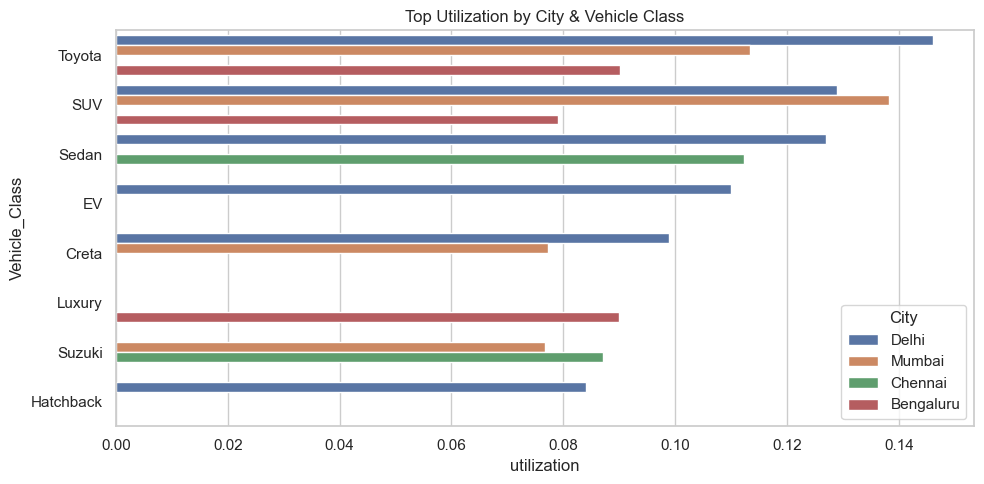

In [3]:
fleet = df.groupby(["City", "Vehicle_Class"], dropna=False)["Vehicle_ID"].nunique().rename("available_cars")
rental = df.loc[df["is_completed"]].groupby(["City", "Vehicle_Class"], dropna=False)["rental_hours"].sum().rename("rental_hours")
util = pd.concat([fleet, rental], axis=1).fillna(0).reset_index()
util["fleet_hours"] = util["available_cars"] * analysis_hours
util["utilization"] = np.where(util["fleet_hours"] > 0, util["rental_hours"] / util["fleet_hours"], 0)
util = util.sort_values("utilization", ascending=False)
print(util.head(12))

plt.figure(figsize=(10, 5))
sns.barplot(data=util.head(15), x="utilization", y="Vehicle_Class", hue="City")
plt.title("Top Utilization by City & Vehicle Class")
plt.tight_layout()
plt.show()


## 2) Revenue per available car (RevPAC) and yield metrics


In [4]:
completed = df[df["is_completed"]].copy()
rev = completed.groupby(["City", "Vehicle_Class"], dropna=False)["Total_Amount"].sum().rename("revenue")
hours = completed.groupby(["City", "Vehicle_Class"], dropna=False)["rental_hours"].sum().rename("rental_hours")
base = completed.assign(base_bill=completed["Rate"] * completed["rental_hours"]).groupby(["City", "Vehicle_Class"], dropna=False)["base_bill"].sum()

rev_metrics = util.set_index(["City", "Vehicle_Class"])[["available_cars"]].join(rev).join(hours).join(base).fillna(0)
rev_metrics = rev_metrics.rename(columns={"base_bill": "base_revenue_proxy"}).reset_index()
rev_metrics["RevPAC"] = np.where(rev_metrics["available_cars"] > 0, rev_metrics["revenue"] / rev_metrics["available_cars"], 0)
rev_metrics["yield_per_hour"] = np.where(rev_metrics["rental_hours"] > 0, rev_metrics["revenue"] / rev_metrics["rental_hours"], 0)
rev_metrics["realization_vs_base"] = np.where(rev_metrics["base_revenue_proxy"] > 0, rev_metrics["revenue"] / rev_metrics["base_revenue_proxy"], np.nan)

print(rev_metrics.sort_values("RevPAC", ascending=False).head(12))


         City Vehicle_Class  available_cars    revenue  rental_hours  \
2       Delhi           SUV              55  145779.68      57835.44   
0       Delhi        Toyota              72  153897.46      85853.55   
3       Delhi         Sedan              71  147788.16      73512.57   
11      Delhi     Hatchback              79  160812.88      54127.42   
7       Delhi         Creta              78  157011.42      62976.93   
18      Delhi        Suzuki              69  125812.84      41519.65   
6       Delhi            EV              67  120293.54      60095.56   
9   Bengaluru        Luxury              58   97871.68      42585.52   
19      Delhi        Luxury              64  107404.84      38345.70   
1      Mumbai           SUV              50   83025.42      56395.49   
30     Mumbai            EV              52   83119.82      16667.18   
5     Chennai         Sedan              59   94165.24      54094.13   

    base_revenue_proxy       RevPAC  yield_per_hour  realizatio

## 3) Distance driven and cost per km


         City Vehicle_Class  total_distance_km  avg_cost_per_km  \
16      Delhi         Creta            16260.0       131.999191   
18      Delhi     Hatchback            15886.0        43.112667   
21      Delhi         Sedan            15632.0        54.941079   
23      Delhi        Toyota            15368.0        36.065450   
20      Delhi           SUV            14357.0        58.576148   
26     Mumbai     Hatchback            13428.0        18.477643   
24     Mumbai         Creta            13229.0        32.420498   
17      Delhi            EV            12526.0        55.737041   
3   Bengaluru        Luxury            11830.0        21.193457   
5   Bengaluru         Sedan            11075.0        63.116851   
22      Delhi        Suzuki            11061.0        76.168356   
19      Delhi        Luxury            10747.0        25.187501   

    median_cost_per_km  
16           11.281442  
18           12.528156  
21            9.469573  
23           10.042553  
20 

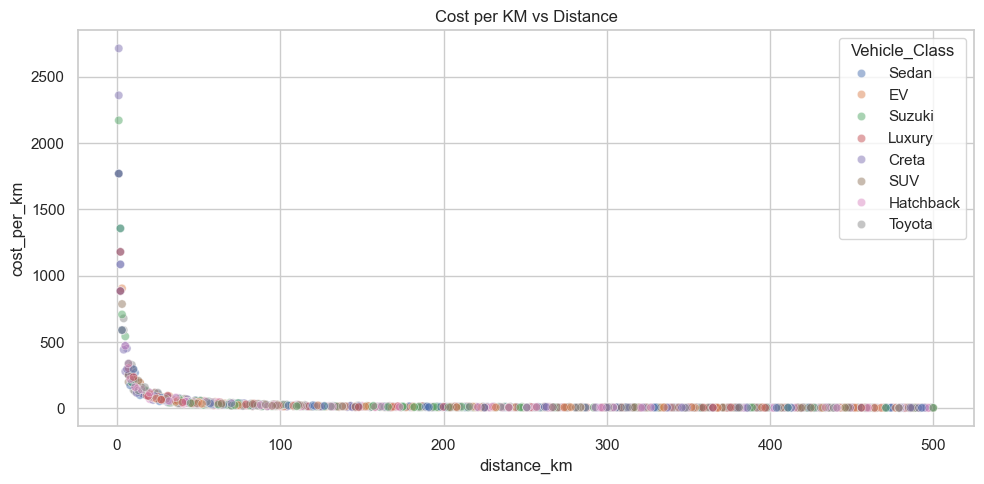

In [5]:
trip = df[(df["is_completed"]) & (df["distance_km"] > 0)].copy()
trip["cost_per_km"] = trip["Total_Amount"] / trip["distance_km"]

distance_cost = trip.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    total_distance_km=("distance_km", "sum"),
    avg_cost_per_km=("cost_per_km", "mean"),
    median_cost_per_km=("cost_per_km", "median"),
).reset_index().sort_values("total_distance_km", ascending=False)

print(distance_cost.head(12))

plt.figure(figsize=(10, 5))
sns.scatterplot(data=trip.sample(min(len(trip), 2000), random_state=42), x="distance_km", y="cost_per_km", hue="Vehicle_Class", alpha=0.5)
plt.title("Cost per KM vs Distance")
plt.tight_layout()
plt.show()


## 4) Idle time and repositioning analytics


In [6]:
seq = df.sort_values(["Vehicle_ID", "Pickup_TS"]).copy()
seq["prev_return_ts"] = seq.groupby("Vehicle_ID")["Return_TS"].shift(1)
seq["prev_city"] = seq.groupby("Vehicle_ID")["City"].shift(1)
seq["idle_hours"] = ((seq["Pickup_TS"] - seq["prev_return_ts"]).dt.total_seconds() / 3600).clip(lower=0)
seq["repositioned"] = (seq["City"] != seq["prev_city"]) & seq["prev_city"].notna()

idle_summary = seq.groupby("Vehicle_Class", dropna=False).agg(
    avg_idle_hours=("idle_hours", "mean"),
    median_idle_hours=("idle_hours", "median"),
    reposition_events=("repositioned", "sum"),
).reset_index().sort_values("avg_idle_hours", ascending=False)

print(idle_summary)


  Vehicle_Class  avg_idle_hours  median_idle_hours  reposition_events
4           SUV      495.343326         188.241667                289
1            EV      481.803962         170.241667                333
0         Creta      478.222608         159.658333                433
3        Luxury      475.944096         133.500000                315
6        Suzuki      467.042567         205.800000                341
5         Sedan      464.105008         177.308333                370
2     Hatchback      457.356566         182.516667                409
7        Toyota      429.917454         163.208333                372


## 5) Dynamic pricing features (demand, lead time, seasonality)


  Reservation_ID     City Vehicle_Class     Rate  lead_time_hours  \
0      RES-00003    Delhi        Suzuki  2000.00             24.0   
1      RES-03655   Mumbai        Suzuki  2300.00             24.0   
2      RES-01774   Mumbai        Suzuki  1840.00             48.0   
3      RES-03809  Chennai        Suzuki  2000.00            216.0   
4      RES-01293   Mumbai        Suzuki  1500.00           2952.0   
5      RES-02593    Delhi        Suzuki  2300.00           1488.0   
6      RES-01461    Delhi        Toyota  1835.27            216.0   
7      RES-02265   Mumbai        Toyota  2000.00            216.0   
8      RES-03309   Mumbai        Toyota  1500.00             24.0   
9      RES-02194  Chennai        Toyota  1500.00             24.0   

   daily_demand  month    weekday  
0             4      3     Monday  
1            14      4     Sunday  
2             6      4    Tuesday  
3             4      6   Saturday  
4             1      9     Monday  
5             9      9  

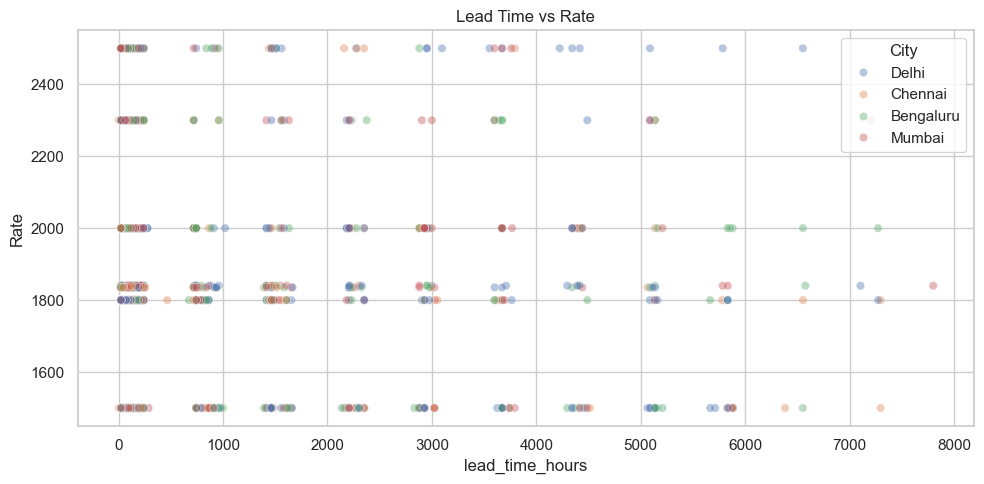

In [7]:
pricing = df.copy()
pricing["month"] = pricing["Pickup_TS"].dt.month
pricing["weekday"] = pricing["Pickup_TS"].dt.day_name()
pricing["daily_demand"] = pricing.groupby(["City", "pickup_date"], dropna=False)["Reservation_ID"].transform("count")

feature_cols = ["Reservation_ID", "City", "Vehicle_Class", "Rate", "lead_time_hours", "daily_demand", "month", "weekday"]
print(pricing[feature_cols].head(10))

plt.figure(figsize=(10, 5))
sns.scatterplot(data=pricing.sample(min(len(pricing), 2000), random_state=42), x="lead_time_hours", y="Rate", hue="City", alpha=0.4)
plt.title("Lead Time vs Rate")
plt.tight_layout()
plt.show()


## 6) Fuel efficiency estimates by model (proxy using Vehicle_Class)


In [8]:
fuel = df[(df["is_completed"]) & (df["distance_km"] > 0)].copy()
fuel["fuel_used_proxy"] = (1 - fuel["Fuel_Level"].fillna(0.5)).clip(lower=0.05, upper=1.0)
fuel["km_per_fuel_proxy"] = fuel["distance_km"] / fuel["fuel_used_proxy"]

fuel_eff = fuel.groupby("Vehicle_Class", dropna=False).agg(
    trips=("Reservation_ID", "count"),
    avg_km_per_fuel_proxy=("km_per_fuel_proxy", "mean"),
    median_km_per_fuel_proxy=("km_per_fuel_proxy", "median"),
).reset_index().sort_values("avg_km_per_fuel_proxy", ascending=False)

print(fuel_eff)


  Vehicle_Class  trips  avg_km_per_fuel_proxy  median_km_per_fuel_proxy
3        Luxury    163            1166.270857                498.666667
6        Suzuki    181            1162.613448                426.000000
0         Creta    210            1054.668265                462.653061
7        Toyota    191             972.356377                460.000000
5         Sedan    191             905.447614                424.285714
2     Hatchback    212             811.673512                397.333333
4           SUV    171             791.947461                416.000000
1            EV    165             733.642053                369.387755


## 7) Damage incidence rate per 100 rentals


In [9]:
damage = df.copy()
damage["damage_event"] = damage["Damage_Flag"].fillna("None").ne("None")

damage_rate = damage.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    rentals=("Reservation_ID", "count"),
    damage_events=("damage_event", "sum"),
).reset_index()
damage_rate["damage_per_100_rentals"] = np.where(damage_rate["rentals"] > 0, 100 * damage_rate["damage_events"] / damage_rate["rentals"], 0)

print(damage_rate.sort_values("damage_per_100_rentals", ascending=False).head(12))


         City Vehicle_Class  rentals  damage_events  damage_per_100_rentals
7   Bengaluru        Toyota      117             91               77.777778
13    Chennai         Sedan      111             82               73.873874
27     Mumbai        Luxury      108             79               73.148148
1   Bengaluru            EV      128             93               72.656250
29     Mumbai         Sedan      117             84               71.794872
31     Mumbai        Toyota      145            103               71.034483
24     Mumbai         Creta      187            132               70.588235
12    Chennai           SUV       80             56               70.000000
30     Mumbai        Suzuki      129             90               69.767442
14    Chennai        Suzuki       94             65               69.148936
16      Delhi         Creta      230            158               68.695652
4   Bengaluru           SUV      113             77               68.141593


## 8) Customer cohort retention and NPS rollups


In [10]:
cust = df.copy()
cust["booking_month_period"] = cust["Booking_TS"].dt.to_period("M")
cohort_month = cust.groupby("Customer_ID")["booking_month_period"].min().rename("cohort_month")
cust = cust.join(cohort_month, on="Customer_ID")

valid = cust.dropna(subset=["booking_month_period", "cohort_month"]).copy()
valid["cohort_index"] = valid["booking_month_period"].astype(int) - valid["cohort_month"].astype(int)

ret_counts = valid.groupby(["cohort_month", "cohort_index"])["Customer_ID"].nunique().unstack(fill_value=0)
if not ret_counts.empty:
    base = ret_counts.iloc[:, 0]
    retention = ret_counts.div(base, axis=0).round(3)
    print("Retention matrix (first rows):")
    print(retention.head())
else:
    print("Retention matrix unavailable (insufficient date data).")

valid["nps_bucket"] = np.select(
    [
        (valid["Driver_Behavior"].eq("Normal Driving") & valid["Damage_Flag"].eq("None")),
        (valid["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | valid["Damage_Flag"].eq("Major")),
    ],
    ["Promoter", "Detractor"],
    default="Passive",
)

nps_rollup = valid.groupby("cohort_month")["nps_bucket"].value_counts(normalize=True).unstack(fill_value=0)
nps_rollup["NPS"] = (nps_rollup.get("Promoter", 0) - nps_rollup.get("Detractor", 0)) * 100
print("\nNPS by cohort month:")
print(nps_rollup[[c for c in ["Promoter", "Passive", "Detractor", "NPS"] if c in nps_rollup.columns]].head(12))


Retention matrix (first rows):
cohort_index   0      1      2      3      4      5      6      7      8   \
cohort_month                                                                
2024-12       1.0  0.299  0.315  0.283  0.236  0.213  0.157  0.008  0.008   
2025-01       1.0  0.311  0.279  0.261  0.283  0.207  0.011  0.010  0.011   
2025-02       1.0  0.352  0.268  0.304  0.263  0.036  0.014  0.003  0.000   
2025-03       1.0  0.288  0.281  0.267  0.014  0.021  0.007  0.007  0.000   
2025-04       1.0  0.224  0.196  0.014  0.007  0.007  0.000  0.000  0.000   

cohort_index     9      10  
cohort_month                
2024-12       0.008  0.008  
2025-01       0.007  0.001  
2025-02       0.000  0.000  
2025-03       0.000  0.000  
2025-04       0.000  0.000  

NPS by cohort month:
nps_bucket     Passive  Detractor         NPS
cohort_month                                 
2024-12       0.339779   0.660221  -66.022099
2025-01       0.342360   0.657640  -65.764023
2025-02       0.3471

## 9) Fraud risk score (short returns, odometer anomalies)


In [11]:
fraud = df.copy()
fraud["short_return_flag"] = fraud["is_completed"] & (fraud["rental_hours"] < 2)
fraud["odo_diff"] = fraud["Odo_End"] - fraud["Odo_Start"]
fraud["odo_anomaly_flag"] = (fraud["odo_diff"] < 0) | ((fraud["odo_diff"] - fraud["distance_km"]).abs() > 50)
fraud["speed_risk_flag"] = fraud["Speed"] > 120
fraud["fraud_risk_score"] = (
    30 * fraud["short_return_flag"].astype(int)
    + 50 * fraud["odo_anomaly_flag"].fillna(False).astype(int)
    + 20 * fraud["speed_risk_flag"].fillna(False).astype(int)
    + 20 * fraud["vehicle_id_invalid_flag"].astype(int)
).clip(0, 100)

fraud_view = fraud[["Reservation_ID", "Customer_ID", "Vehicle_ID", "City", "fraud_risk_score", "short_return_flag", "odo_anomaly_flag", "speed_risk_flag", "vehicle_id_invalid_flag"]]
print(fraud_view.sort_values("fraud_risk_score", ascending=False).head(20))


     Reservation_ID Customer_ID Vehicle_ID       City  fraud_risk_score  \
1638      RES-02411   CUST-1091    CAR-221     Mumbai                50   
1179      RES-00705   CUST-1275    CAR-161  Bengaluru                50   
162       RES-00587   CUST-0711    CAR-022     Mumbai                50   
65        RES-04387   CUST-0081    CAR-010      Delhi                50   
2761      RES-02492   CUST-1845    CAR-368      Delhi                50   
2906      RES-03534   CUST-0054    CAR-388    Chennai                50   
207       RES-02627   CUST-1521    CAR-027     Mumbai                50   
2469      RES-02750   CUST-0798    CAR-334  Bengaluru                50   
3044      RES-02534   CUST-1429    CAR-407     Mumbai                50   
4515      RES-01041   CUST-0416    CAR-600    Chennai                40   
4520      RES-00590   CUST-1291    CAR-600      Delhi                40   
4517      RES-03681   CUST-1584    CAR-600     Mumbai                40   
1521      RES-02088   CUS

## 10) Maintenance due forecast (km/time based)


In [12]:
latest = df.sort_values("Return_TS").groupby("Vehicle_ID", as_index=False).tail(1).copy()
latest["current_odometer"] = latest["Odo_End"].fillna(latest["Odo_Start"])
latest["km_to_next_service"] = 10000 - (latest["current_odometer"] % 10000)
latest["days_since_last_return"] = (pd.Timestamp.today().normalize() - latest["Return_TS"]).dt.days

latest["maintenance_due"] = (latest["km_to_next_service"] <= 500) | (latest["days_since_last_return"] >= 180)
latest["maintenance_priority"] = (
    ((500 - latest["km_to_next_service"]).clip(lower=0) / 500) * 0.6
    + (latest["days_since_last_return"].fillna(0).clip(lower=0) / 180).clip(upper=2) * 0.4
)

print(latest[["Vehicle_ID", "Vehicle_Class", "current_odometer", "km_to_next_service", "days_since_last_return", "maintenance_due", "maintenance_priority"]].sort_values(["maintenance_due", "maintenance_priority"], ascending=[False, False]).head(20))


     Vehicle_ID Vehicle_Class  current_odometer  km_to_next_service  \
2473    CAR-335        Suzuki           59952.0                48.0   
2600    CAR-351        Toyota           49972.0                28.0   
2784    CAR-370         Creta           79942.0                58.0   
3670    CAR-494        Luxury           59872.0               128.0   
3098    CAR-414        Luxury           49907.0                93.0   
3829    CAR-515         Creta           19901.0                99.0   
2100    CAR-284        Toyota           39778.0               222.0   
1816    CAR-245         Sedan           79805.0               195.0   
4372    CAR-581        Toyota           39775.0               225.0   
3118    CAR-416        Suzuki           39746.0               254.0   
1519    CAR-207     Hatchback           59952.0                48.0   
1839    CAR-248     Hatchback           59725.0               275.0   
3221    CAR-432            EV           56071.0              3929.0   
518   

## 11) Overstay detection and penalty calculation


In [13]:
overstay = df[df["is_completed"]].copy()
overstay["expected_hours_from_bill"] = np.where(overstay["Rate"] > 0, overstay["Total_Amount"] / overstay["Rate"], np.nan)
overstay["overstay_hours"] = (overstay["rental_hours"] - overstay["expected_hours_from_bill"]).clip(lower=0)
overstay["overstay_penalty"] = overstay["overstay_hours"] * 0.25 * overstay["Rate"]

print(overstay[["Reservation_ID", "City", "Vehicle_Class", "rental_hours", "expected_hours_from_bill", "overstay_hours", "overstay_penalty"]].sort_values("overstay_penalty", ascending=False).head(20))


     Reservation_ID       City Vehicle_Class  rental_hours  \
1485      RES-01171      Delhi         Sedan       7712.17   
1334      RES-00053  Bengaluru         Sedan       7059.00   
2475      RES-02007    Chennai        Luxury       6975.00   
2005      RES-03090      Delhi        Toyota       6440.43   
2560      RES-02693      Delhi        Toyota       6369.00   
208       RES-03944     Mumbai     Hatchback       6334.00   
2026      RES-01485    Chennai     Hatchback       6318.00   
3104      RES-03524    Chennai        Suzuki       6264.78   
3508      RES-04078    Chennai           SUV       6370.72   
429       RES-02367  Bengaluru        Toyota       7754.18   
389       RES-03865  Bengaluru         Creta       7104.00   
893       RES-03388    Chennai         Sedan       7725.72   
4210      RES-03577    Chennai     Hatchback       7701.00   
2142      RES-01654    Chennai        Toyota       5616.00   
2421      RES-03356      Delhi        Toyota       7016.00   
4148    

## 12) Pickup/return punctuality stats


Assumption for punctuality (proxy):
- `scheduled_pickup = Booking_TS + 24 hours`
- return punctuality is measured by difference between computed actual duration and provided duration field.


In [14]:
punct = df.copy()
punct["scheduled_pickup"] = punct["Booking_TS"] + pd.Timedelta(hours=24)
punct["pickup_delay_min"] = (punct["Pickup_TS"] - punct["scheduled_pickup"]).dt.total_seconds() / 60

punct["actual_duration_hours"] = (punct["Return_TS"] - punct["Pickup_TS"]).dt.total_seconds() / 3600
punct["return_delay_min"] = (punct["actual_duration_hours"] - punct["Duration_Hours"]).fillna(0) * 60

punct["pickup_on_time"] = punct["pickup_delay_min"].abs() <= 30
punct["return_on_time"] = punct["return_delay_min"].abs() <= 30

punct_stats = punct.groupby("City", dropna=False).agg(
    pickup_on_time_rate=("pickup_on_time", "mean"),
    return_on_time_rate=("return_on_time", "mean"),
    avg_pickup_delay_min=("pickup_delay_min", "mean"),
    avg_return_delay_min=("return_delay_min", "mean"),
).reset_index()

punct_stats["pickup_on_time_rate"] = (punct_stats["pickup_on_time_rate"] * 100).round(2)
punct_stats["return_on_time_rate"] = (punct_stats["return_on_time_rate"] * 100).round(2)
print(punct_stats.round(2))


        City  pickup_on_time_rate  return_on_time_rate  avg_pickup_delay_min  \
0  Bengaluru                32.66                98.75              38137.15   
1    Chennai                32.33                99.62              35148.42   
2      Delhi                35.59                99.39              37311.89   
3     Mumbai                32.89                99.43              30992.51   

   avg_return_delay_min  
0                623.46  
1                187.69  
2                306.85  
3                282.33  


## 13) Geo heatmaps of pickup/drop hotspots


Drop coordinates are not separately available; pickup geo points are used as hotspot proxy.


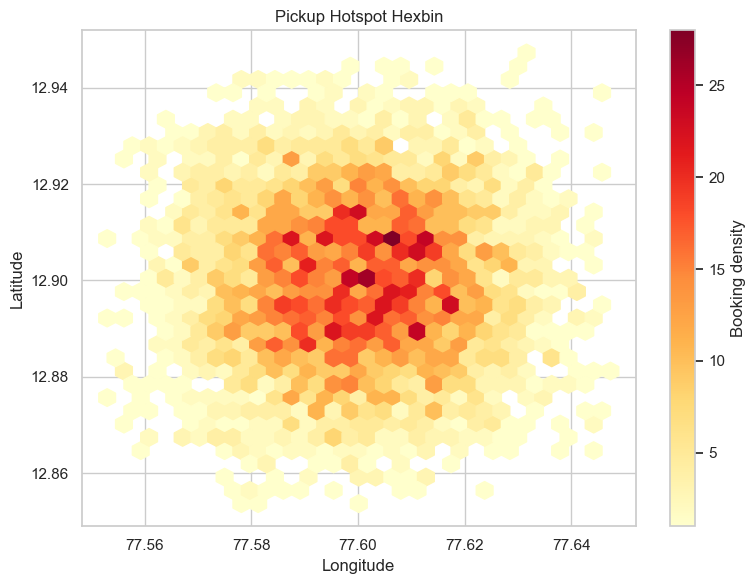

          City  lat_bin  lon_bin  bookings
176      Delhi    12.89    77.60        80
187      Delhi    12.90    77.61        76
186      Delhi    12.90    77.60        73
196      Delhi    12.91    77.60        70
195      Delhi    12.91    77.59        68
197      Delhi    12.91    77.61        66
175      Delhi    12.89    77.59        61
46   Bengaluru    12.91    77.61        59
185      Delhi    12.90    77.59        57
258     Mumbai    12.90    77.60        53
257     Mumbai    12.90    77.59        52
177      Delhi    12.89    77.61        52
268     Mumbai    12.91    77.61        51
204      Delhi    12.92    77.60        50
178      Delhi    12.89    77.62        49


In [15]:
geo = df.dropna(subset=["GPS_Lat", "GPS_Lon"]).copy()

plt.figure(figsize=(8, 6))
plt.hexbin(geo["GPS_Lon"], geo["GPS_Lat"], gridsize=30, cmap="YlOrRd", mincnt=1)
plt.colorbar(label="Booking density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pickup Hotspot Hexbin")
plt.tight_layout()
plt.show()

hotspots = (
    geo.assign(lat_bin=geo["GPS_Lat"].round(2), lon_bin=geo["GPS_Lon"].round(2))
       .groupby(["City", "lat_bin", "lon_bin"], dropna=False)
       .size()
       .reset_index(name="bookings")
       .sort_values("bookings", ascending=False)
)
print(hotspots.head(15))


## 14) Upsell/cross-sell opportunity flags (addons)


In [16]:
upsell = df.copy()
notes = upsell["Notes"].fillna("").str.lower()

upsell["addon_navigation"] = notes.str.contains("navigation")
upsell["addon_cleaning"] = notes.str.contains("clean")
upsell["addon_fuel_plan"] = notes.str.contains("fuel") | (upsell["Fuel_Level"].fillna(0.5) < 0.25)
upsell["addon_protection"] = upsell["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | upsell["Damage_Flag"].isin(["Minor", "Major"])

flag_cols = ["addon_navigation", "addon_cleaning", "addon_fuel_plan", "addon_protection"]
upsell["upsell_flag_count"] = upsell[flag_cols].sum(axis=1)
upsell["upsell_opportunity"] = upsell["upsell_flag_count"] > 0

upsell_summary = upsell.groupby("City", dropna=False).agg(
    rentals=("Reservation_ID", "count"),
    opportunities=("upsell_opportunity", "sum"),
).reset_index()
upsell_summary["opportunity_rate"] = 100 * upsell_summary["opportunities"] / upsell_summary["rentals"]

print(upsell_summary.sort_values("opportunity_rate", ascending=False))


        City  rentals  opportunities  opportunity_rate
3     Mumbai     1061            953         89.820924
1    Chennai      798            714         89.473684
2      Delhi     1627           1443         88.690842
0  Bengaluru     1041            920         88.376561


## 15) Cancellation rate and reasons analysis


In [17]:
cancel = df.copy()
cancel["is_cancelled"] = cancel["Booking_Status"].isin(["Cancelled", "No_Show"])
notes = cancel["Notes"].fillna("").str.lower()

cancel["cancel_reason_bucket"] = np.select(
    [
        notes.str.contains("traffic"),
        notes.str.contains("fuel"),
        notes.str.contains("clean"),
        notes.str.contains("scratch|damage"),
        notes.str.contains("early pickup"),
        notes.str.contains("no notes"),
    ],
    ["Traffic", "Fuel", "Cleaning", "Damage Concern", "Schedule Change", "Unspecified"],
    default="Other",
)

cancel_rate = cancel.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    total_bookings=("Reservation_ID", "count"),
    cancelled=("is_cancelled", "sum"),
).reset_index()
cancel_rate["cancellation_rate"] = 100 * cancel_rate["cancelled"] / cancel_rate["total_bookings"]

reason_dist = cancel[cancel["is_cancelled"]].groupby("cancel_reason_bucket").size().reset_index(name="count").sort_values("count", ascending=False)

print(cancel_rate.sort_values("cancellation_rate", ascending=False).head(12))
print("\nCancellation reason distribution:")
print(reason_dist)


         City Vehicle_Class  total_bookings  cancelled  cancellation_rate
19      Delhi        Luxury             189        139          73.544974
5   Bengaluru         Sedan             136         96          70.588235
24     Mumbai         Creta             187        132          70.588235
22      Delhi        Suzuki             200        141          70.500000
27     Mumbai        Luxury             108         76          70.370370
1   Bengaluru            EV             128         90          70.312500
2   Bengaluru     Hatchback             151        106          70.198675
29     Mumbai         Sedan             117         82          70.085470
12    Chennai           SUV              80         56          70.000000
31     Mumbai        Toyota             145        100          68.965517
8     Chennai         Creta             106         73          68.867925
0   Bengaluru         Creta             154        106          68.831169

Cancellation reason distribution:
  c

## 16) Driver behavior scoring from telematics


In [18]:
driver = df.copy()
driver["driver_score"] = 100

driver["driver_score"] = driver["driver_score"] - np.where(driver["Speed"] > 120, 30, np.where(driver["Speed"] > 100, 15, 0))
driver["driver_score"] = driver["driver_score"] - np.where(driver["Driver_Behavior"].eq("Speeding"), 25, np.where(driver["Driver_Behavior"].eq("Fast Driving"), 10, 0))
driver["driver_score"] = driver["driver_score"] - np.where(driver["Damage_Flag"].eq("Major"), 20, np.where(driver["Damage_Flag"].eq("Minor"), 8, 0))
driver["driver_score"] = driver["driver_score"].clip(lower=0, upper=100)

driver_summary = driver.groupby("Customer_ID", dropna=False).agg(
    trips=("Reservation_ID", "count"),
    avg_driver_score=("driver_score", "mean"),
).reset_index().sort_values("avg_driver_score")

print(driver_summary.head(20))


     Customer_ID  trips  avg_driver_score
1256   CUST-1388      1              25.0
811    CUST-0892      1              25.0
346    CUST-0375      1              25.0
717    CUST-0787      2              25.0
1683   CUST-1858      1              25.0
1673   CUST-1847      1              25.0
1170   CUST-1289      2              25.0
443    CUST-0483      1              25.0
143    CUST-0154      1              25.0
457    CUST-0497      2              25.0
967    CUST-1062      1              25.0
551    CUST-0596      1              25.0
1022   CUST-1126      1              25.0
1071   CUST-1179      1              25.0
596    CUST-0644      1              25.0
1580   CUST-1748      1              25.0
1478   CUST-1636      1              25.0
1276   CUST-1410      1              25.0
1020   CUST-1124      2              31.0
1460   CUST-1616      2              35.0


## 17) Vehicle class mix optimization


In [19]:
mix = util.merge(rev_metrics[["City", "Vehicle_Class", "RevPAC"]], on=["City", "Vehicle_Class"], how="left")
mix["fleet_share"] = mix.groupby("City")["available_cars"].transform(lambda s: s / max(s.sum(), 1))

mix["util_norm"] = mix.groupby("City")["utilization"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["rev_norm"] = mix.groupby("City")["RevPAC"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["mix_score"] = 0.6 * mix["util_norm"] + 0.4 * mix["rev_norm"]

mix["mix_action"] = np.where(mix["mix_score"] >= 0.66, "Increase share", np.where(mix["mix_score"] >= 0.33, "Hold / optimize", "Reduce share"))

print(mix.sort_values(["City", "mix_score"], ascending=[True, False]))


         City Vehicle_Class  available_cars  rental_hours  fleet_hours  \
9   Bengaluru        Luxury              58      42585.52    473230.70   
8   Bengaluru        Toyota              58      42669.97    473230.70   
12  Bengaluru           SUV              52      33577.08    424275.80   
17  Bengaluru        Suzuki              62      37669.20    505867.30   
21  Bengaluru     Hatchback              70      37369.52    571140.50   
26  Bengaluru         Creta              72      34010.07    587458.80   
29  Bengaluru         Sedan              65      29979.12    530344.75   
27  Bengaluru            EV              61      28665.80    497708.15   
5     Chennai         Sedan              59      54094.13    481389.85   
10    Chennai        Suzuki              46      32709.91    375320.90   
20    Chennai        Toyota              58      33437.33    473230.70   
22    Chennai        Luxury              51      26950.78    416116.65   
15    Chennai     Hatchback           

## 18) Lead-time price elasticity features


In [20]:
elastic = df.copy()
elastic["week"] = elastic["Booking_TS"].dt.to_period("W").astype(str)
weekly = elastic.groupby(["City", "Vehicle_Class", "week"], dropna=False).agg(
    bookings=("Reservation_ID", "count"),
    avg_rate=("Rate", "mean"),
    avg_lead_time=("lead_time_hours", "mean"),
).reset_index()

def elasticity_proxy(g):
    g = g[(g["bookings"] > 0) & (g["avg_rate"] > 0)].dropna(subset=["bookings", "avg_rate"])
    if len(g) < 3 or g["avg_rate"].nunique() < 2:
        return np.nan
    x = np.log(g["avg_rate"])
    y = np.log(g["bookings"])
    return np.cov(x, y, bias=True)[0, 1] / (np.var(x) + 1e-9)

elasticity_table = weekly.groupby(["City", "Vehicle_Class"], dropna=False).apply(elasticity_proxy).reset_index(name="price_elasticity")
print(elasticity_table.sort_values("price_elasticity").head(20))


         City Vehicle_Class  price_elasticity
24     Mumbai         Creta         -3.818735
8     Chennai         Creta         -2.353911
3   Bengaluru        Luxury         -1.571471
0   Bengaluru         Creta         -1.510694
9     Chennai            EV         -1.483808
21      Delhi         Sedan         -0.790621
26     Mumbai     Hatchback         -0.762428
31     Mumbai        Toyota         -0.592416
12    Chennai           SUV         -0.439939
23      Delhi        Toyota         -0.232155
22      Delhi        Suzuki         -0.138263
18      Delhi     Hatchback         -0.106694
4   Bengaluru           SUV          0.376248
1   Bengaluru            EV          0.391403
11    Chennai        Luxury          0.401689
15    Chennai        Toyota          0.568928
13    Chennai         Sedan          0.813034
10    Chennai     Hatchback          0.973582
28     Mumbai           SUV          0.981999
27     Mumbai        Luxury          0.996151


## 19) Fleet health score combining faults and usage


In [21]:
health_src = df.copy()
notes = health_src["Notes"].fillna("").str.lower()
health_src["fault_points"] = (
    np.where(health_src["Damage_Flag"].eq("Major"), 20, 0)
    + np.where(health_src["Damage_Flag"].eq("Minor"), 10, 0)
    + np.where(notes.str.contains("alert|malfunction|scratch"), 8, 0)
)
health_src["usage_hours_component"] = np.where(health_src["is_completed"], health_src["rental_hours"].fillna(0), 0)

health = health_src.groupby(["Vehicle_ID", "Vehicle_Class"], dropna=False).agg(
    fault_points=("fault_points", "sum"),
    usage_hours=("usage_hours_component", "sum"),
    avg_speed=("Speed", "mean"),
    rentals=("Reservation_ID", "count"),
).reset_index()

health["fault_norm"] = health["fault_points"] / (health["fault_points"].max() + 1e-9)
health["usage_norm"] = health["usage_hours"] / (health["usage_hours"].max() + 1e-9)
health["speed_norm"] = (health["avg_speed"].fillna(0) / 120).clip(0, 1)

health["fleet_health_score"] = 100 - (50 * health["fault_norm"] + 30 * health["usage_norm"] + 20 * health["speed_norm"])
health["fleet_health_score"] = health["fleet_health_score"].clip(0, 100)

print(health.sort_values("fleet_health_score").head(20))


    Vehicle_ID Vehicle_Class  fault_points  usage_hours   avg_speed  rentals  \
471    CAR-472           SUV           154     17720.62   94.666667       12   
599    CAR-600        Toyota           250      3759.65   88.350000       20   
72     CAR-073        Toyota           220      8512.42   72.727273       11   
441    CAR-442            EV           204      8612.46   85.733333       15   
26     CAR-028     Hatchback           202      6517.23  101.076923       13   
561    CAR-562     Hatchback           204      8529.92   74.923077       13   
342    CAR-343        Toyota           174     10564.00   84.000000       14   
357    CAR-358         Sedan           140     13496.49   84.000000        9   
284    CAR-285         Sedan           220      3090.55   90.214286       14   
568    CAR-569         Creta           166      9094.22   84.500000       12   
195    CAR-196         Creta           198      4243.00   92.769231       13   
28     CAR-030        Toyota           2

## 20) Churn likelihood for subscription rentals


Subscription proxy: customers with at least 3 bookings in the dataset are treated as subscription-like customers.


In [22]:
churn_src = df.copy()
churn_src["booking_date"] = churn_src["Booking_TS"].dt.floor("D")

cust_counts = churn_src.groupby("Customer_ID")["Reservation_ID"].count().rename("total_bookings")
subs = cust_counts[cust_counts >= 3].index
sub_df = churn_src[churn_src["Customer_ID"].isin(subs)].copy()

snapshot = sub_df["booking_date"].max() + pd.Timedelta(days=1) if not sub_df.empty else pd.Timestamp.today().normalize()

last_booking = sub_df.groupby("Customer_ID")["booking_date"].max().rename("last_booking")
sub_df["days_ago"] = (snapshot - sub_df["booking_date"]).dt.days

recent_90 = sub_df[sub_df["days_ago"] <= 90].groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_recent_90")
prev_90 = sub_df[(sub_df["days_ago"] > 90) & (sub_df["days_ago"] <= 180)].groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_prev_90")

churn = pd.concat([cust_counts, last_booking, recent_90, prev_90], axis=1).fillna(0)
churn = churn.loc[churn.index.isin(subs)].copy()

churn["days_since_last_booking"] = (snapshot - pd.to_datetime(churn["last_booking"])) .dt.days
churn["drop_ratio"] = np.where(churn["bookings_prev_90"] > 0, (churn["bookings_prev_90"] - churn["bookings_recent_90"]) / churn["bookings_prev_90"], 0)

churn["recency_norm"] = (churn["days_since_last_booking"] / 90).clip(0, 1)
churn["drop_norm"] = churn["drop_ratio"].clip(0, 1)
churn["churn_likelihood"] = (0.6 * churn["recency_norm"] + 0.4 * churn["drop_norm"]).clip(0, 1)
churn["churn_band"] = pd.cut(churn["churn_likelihood"], bins=[-0.01, 0.33, 0.66, 1.0], labels=["Low", "Medium", "High"])

print(churn.sort_values("churn_likelihood", ascending=False).head(20))


             total_bookings         last_booking  bookings_recent_90  \
Customer_ID                                                            
CUST-1997                 4  2025-06-20 00:00:00                 0.0   
CUST-0004                 3  2025-06-16 00:00:00                 0.0   
CUST-0007                 5  2025-06-24 00:00:00                 0.0   
CUST-0008                 3  2025-06-18 00:00:00                 0.0   
CUST-0011                 5  2025-06-17 00:00:00                 0.0   
CUST-0014                 4  2025-05-23 00:00:00                 0.0   
CUST-0015                 3  2025-06-15 00:00:00                 0.0   
CUST-0017                 4  2025-06-16 00:00:00                 0.0   
CUST-0018                 3  2025-05-16 00:00:00                 0.0   
CUST-1957                 5  2025-06-17 00:00:00                 0.0   
CUST-1953                 3  2025-07-06 00:00:00                 0.0   
CUST-1949                 5  2025-06-18 00:00:00                

## Done
All 20 transformations are included above with simple, reusable logic.
